In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX

Setup constants

In [2]:
X_VARS: list[str] = [
    "life_expectancy_at_birth",
    "gdp_per_capita_2015_dollar",
    "physicians_per_1000",
    "hospital_beds_per_1000",
    "crop_production_index",
]

Y_COL: str = "total_fertility_rate"

TIME_COL: str = "year"
COUNTRY_COL: str = "country_name"

In [3]:
df = pd.read_csv("../data/wdi_fertility_data_filled_filtered.csv")

# Fix time index
df.index = pd.to_datetime(df[TIME_COL], format="%Y")
df = df.drop(columns=[TIME_COL])
df.index = df.index.to_period("Y")

df.head()

,country_name,gdp_per_capita_2015_dollar,physicians_per_1000,hospital_beds_per_1000,crop_production_index,life_expectancy_at_birth,total_fertility_rate
year,,,,,,,
1990,Argentina,8144.494294,2.680,4.5943,39.14,71.784000,3.034
1990,Brazil,6086.077553,1.074,3.3453,41.03,65.985000,2.905
1990,France,28617.443570,3.118,9.7000,98.60,76.600000,1.770
1990,Germany,29485.709970,2.762,10.4000,89.56,75.085634,1.450
1990,Poland,5111.345330,2.145,5.7000,128.14,70.890244,2.060


Split into train/test

In [4]:
df_train = df.loc[df.index <= "2015"]
df_test = df.loc[df.index > "2015"]

df_train.shape, df_test.shape

((260, 7), (50, 7))

Auto ARIMA to determine (p, d, q) orders

In [5]:
import warnings

# Suppress the specific FutureWarning from sklearn
warnings.filterwarnings(
    "ignore", category=FutureWarning, module="sklearn.utils.deprecation"
)

orders_per_country = {}

for country in df_train[COUNTRY_COL].unique():
    country_df = df_train[df_train[COUNTRY_COL] == country]

    arima_model = auto_arima(
        country_df[Y_COL],
        exogenous=country_df[X_VARS],
        seasonal=False,
        stepwise=True,
        suppress_warnings=True,
        error_action="ignore",
    )

    orders_per_country[country] = arima_model.order

orders_per_country

{'Argentina': (0, 2, 0),
 'Brazil': (0, 2, 0),
 'France': (0, 1, 0),
 'Germany': (0, 1, 1),
 'Poland': (1, 2, 0),
 'Nigeria': (1, 1, 1),
 'Kenya': (2, 1, 1),
 'United Kingdom': (1, 0, 2),
 'China': (2, 0, 0),
 'Japan': (1, 0, 2)}

Fit SARIMAX country models

In [6]:
sarmiax_models_per_country = {}

for country in df_train[COUNTRY_COL].unique():
    country_df = df_train[df_train[COUNTRY_COL] == country]

    model = SARIMAX(
        endog=country_df[Y_COL],
        exog=country_df[X_VARS],
        order=orders_per_country[country],
        enforce_stationarity=False,
        enforce_invertibility=False,
    )

    model_fit = model.fit()

    print(f"SARIMAX model for {country}: \n{model_fit.summary()}\n\n")

    sarmiax_models_per_country[country] = model_fit

 This problem is unconstrained.

 Line search cannot locate an adequate point after MAXLS
  function and gradient evaluations.
  Previous x, f and g restored.
 Possible causes: 1 error in function or gradient evaluation;
                  2 rounding error dominate computation.
/Users/kacperkedzierski/Documents/Code/Repositories/fertility-prognosing/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
 This problem is unconstrained.

 Bad direction in the line search;
   refresh the lbfgs memory and restart the iteration.

   evaluations in the last line search.  Termination
   may possibly be caused by a bad search direction.
 This problem is unconstrained.
/Users/kacperkedzierski/Documents/Code/Repositories/fertility-prognosing/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Lik

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            6     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f= -1.38141D+00    |proj g|=  4.45877D+02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    6      1     21      1     0     0   4.459D+02  -1.381D+00
  F =  -1.3814089358147383     

ABNORMAL_TERMINATION_IN_LNSRCH                              
SARIMAX model for Argentina: 
                                SARIMAX Results                                 
Dep. Variable:     total_fertility_rate   No. Observations:                   26
Mo


 Bad direction in the line search;
   refresh the lbfgs memory and restart the iteration.

   evaluations in the last line search.  Termination
   may possibly be caused by a bad search direction.
 This problem is unconstrained.
/Users/kacperkedzierski/Documents/Code/Repositories/fertility-prognosing/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
 This problem is unconstrained.

 Bad direction in the line search;
   refresh the lbfgs memory and restart the iteration.



           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    9      2     55      2     0     0   2.189D+06  -1.633D+00
  F =  -1.6332015706197447     

ABNORMAL_TERMINATION_IN_LNSRCH                              
SARIMAX model for United Kingdom: 
                                SARIMAX Results                                 
Dep. Variable:     total_fertility_rate   No. Observations:                   26
Model:                 SARIMAX(1, 0, 2)   Log Likelihood                  42.463
Date:                  Mon, 06 Jan 2025   AIC                            -66.926
Time:                          00:20:15   BIC                   

/Users/kacperkedzierski/Documents/Code/Repositories/fertility-prognosing/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "

 Line search cannot locate an adequate point after MAXLS
  function and gradient evaluations.
  Previous x, f and g restored.
 Possible causes: 1 error in function or gradient evaluation;
                  2 rounding error dominate computation.
 This problem is unconstrained.

 Bad direction in the line search;
   refresh the lbfgs memory and restart the iteration.
/Users/kacperkedzierski/Documents/Code/Repositories/fertility-prognosing/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "

 Line search cannot locate an adequate point after

Plot forecast vs observed on test split

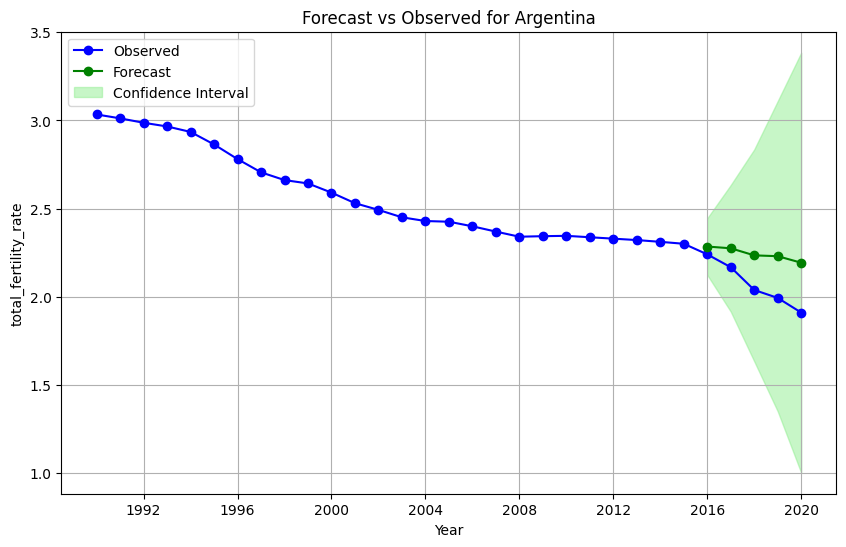

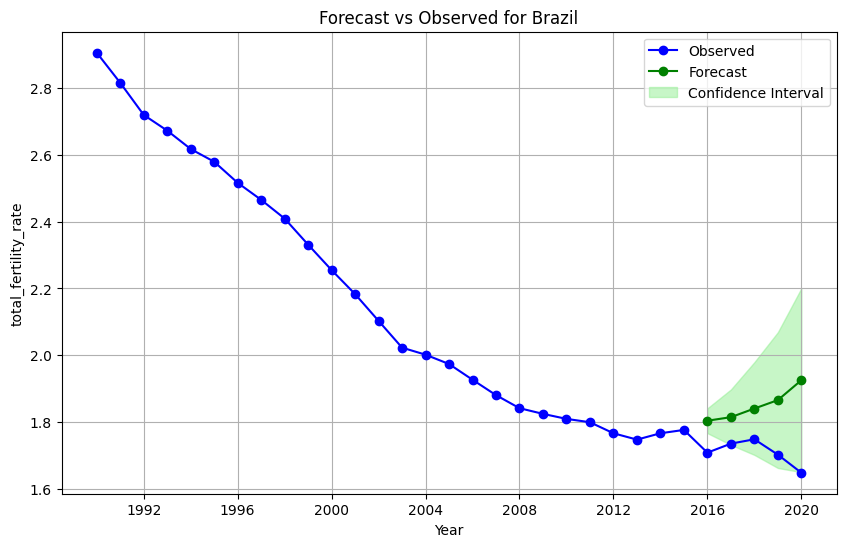

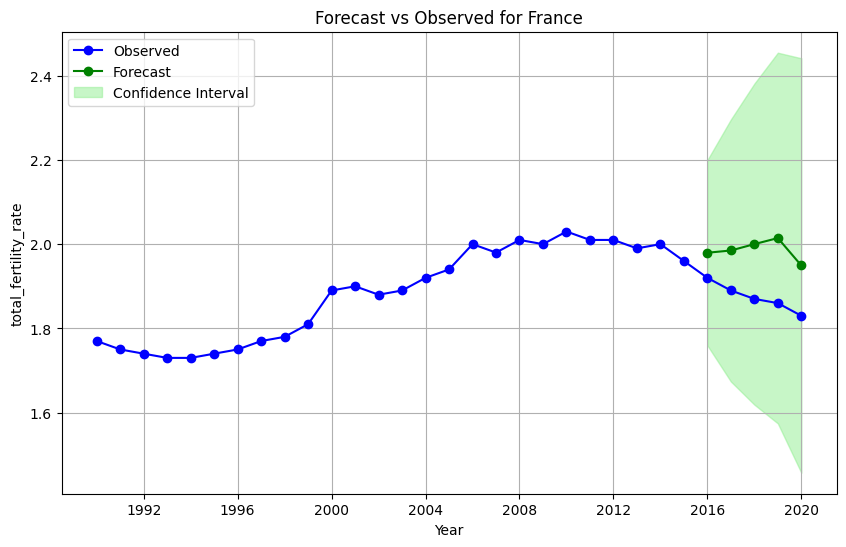

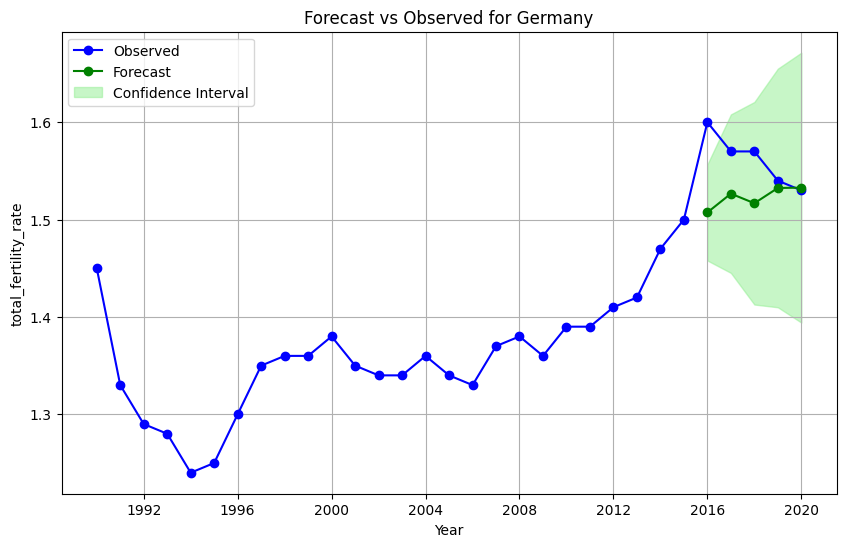

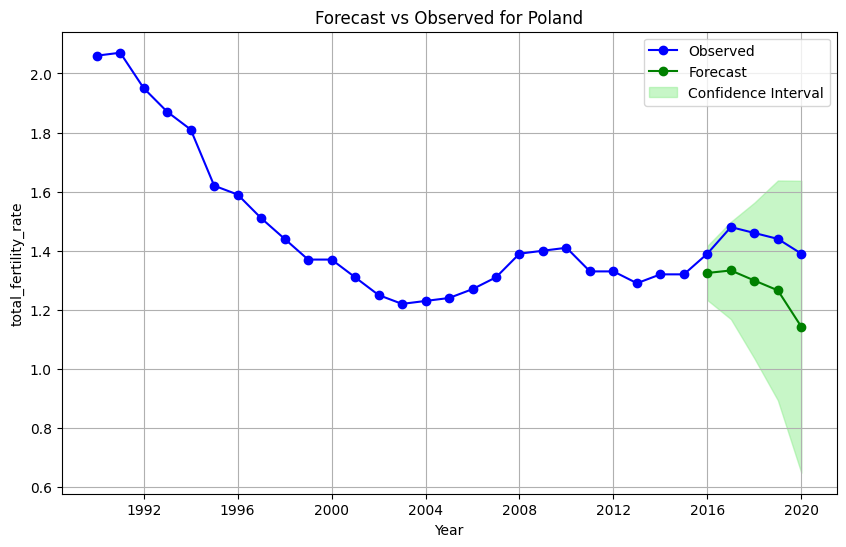

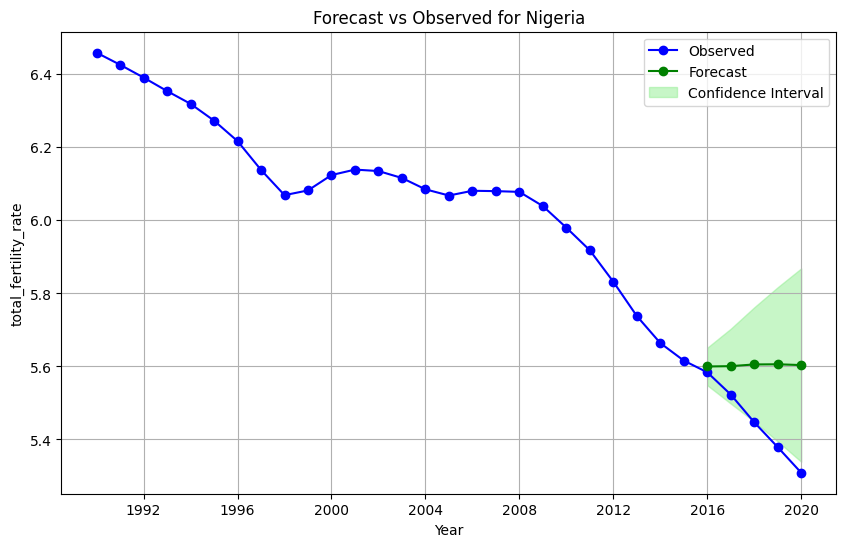

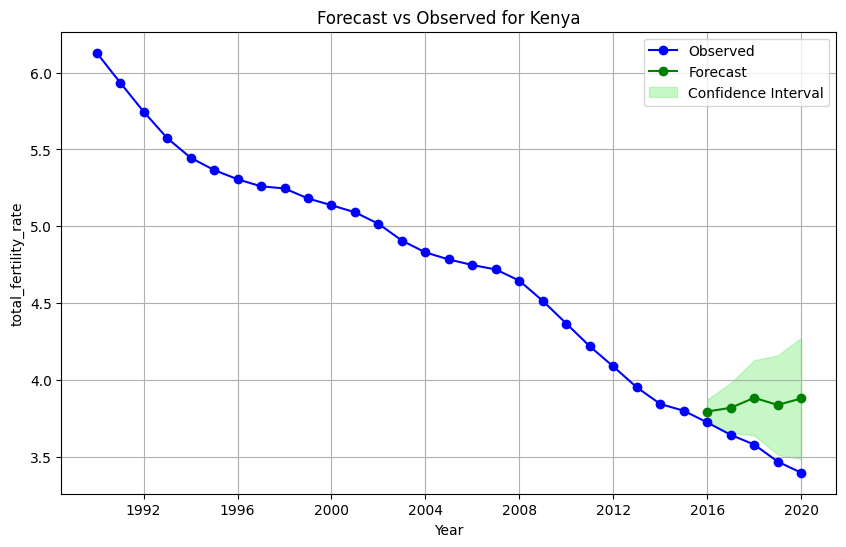

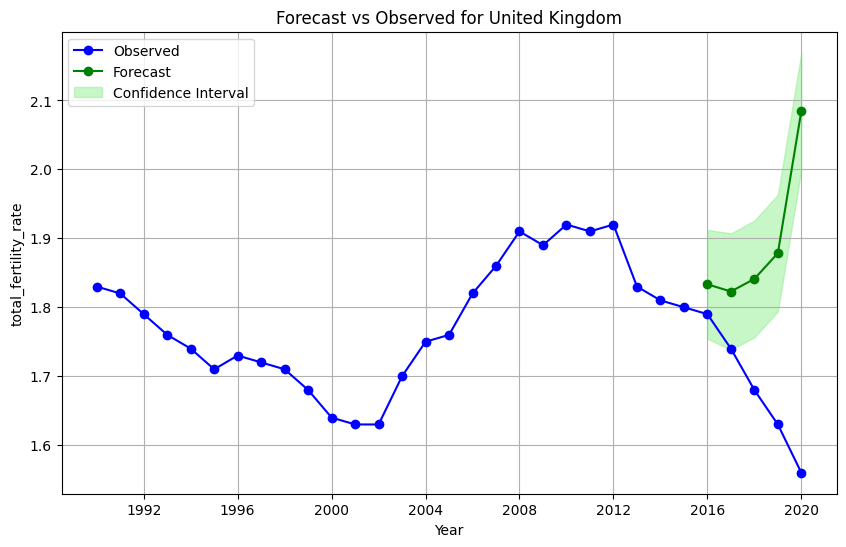

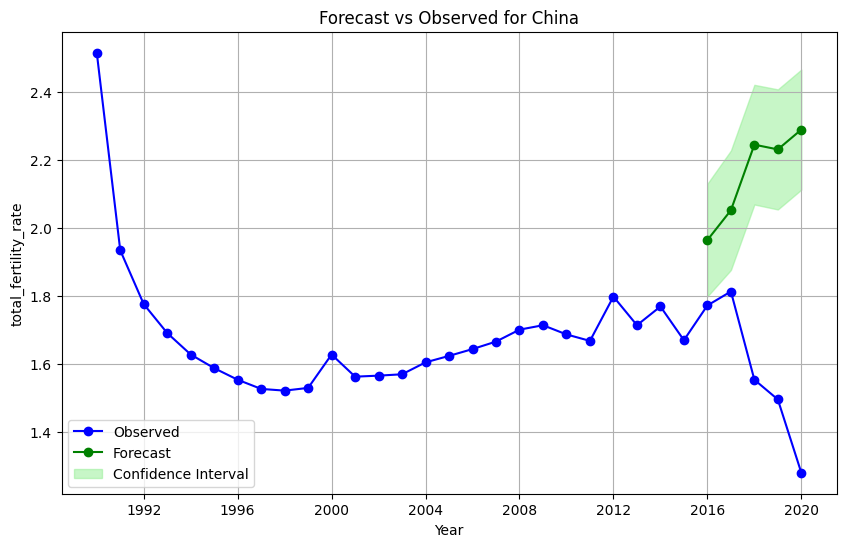

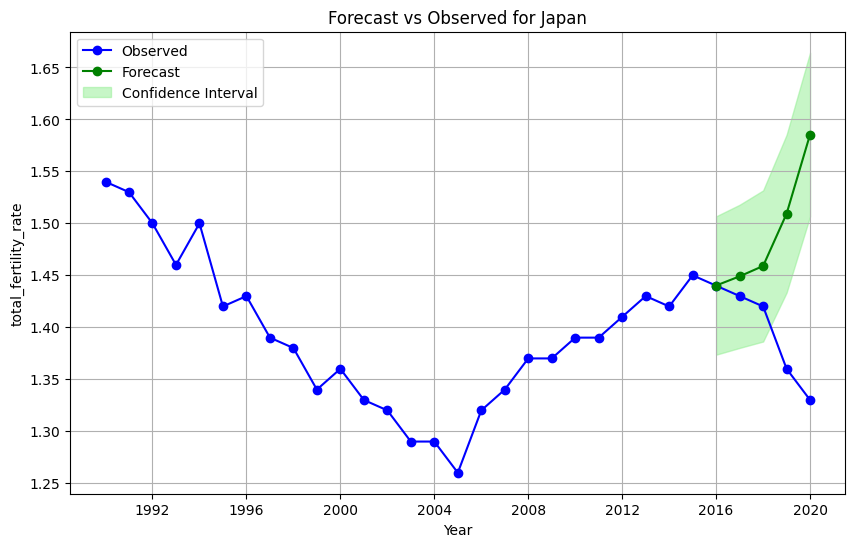

In [7]:
# Generate forecasts and plot for each country
for country in df_test[COUNTRY_COL].unique():
    country_df_train = df_train[df_train[COUNTRY_COL] == country]
    country_df_test = df_test[df_test[COUNTRY_COL] == country]
    country_df = df[df[COUNTRY_COL] == country]

    model_fit = sarmiax_models_per_country[country]

    forecast_steps = len(country_df_test)
    forecast = model_fit.get_forecast(
        steps=forecast_steps, exog=country_df_test[X_VARS]
    )
    forecast_mean = forecast.predicted_mean
    forecast_ci = forecast.conf_int()

    plt.figure(figsize=(10, 6))
    plt.plot(
        country_df.index.to_timestamp(),
        country_df[Y_COL],
        label="Observed",
        marker="o",
        color="blue",
    )
    plt.plot(
        forecast_mean.index.to_timestamp(),
        forecast_mean,
        label="Forecast",
        marker="o",
        color="green",
    )
    plt.fill_between(
        forecast_ci.index.to_timestamp(),
        forecast_ci.iloc[:, 0],
        forecast_ci.iloc[:, 1],
        color="lightgreen",
        alpha=0.5,
        label="Confidence Interval",
    )

    plt.title(f"Forecast vs Observed for {country}")
    plt.xlabel("Year")
    plt.ylabel(Y_COL)
    plt.legend()
    plt.grid()

    plt.show()

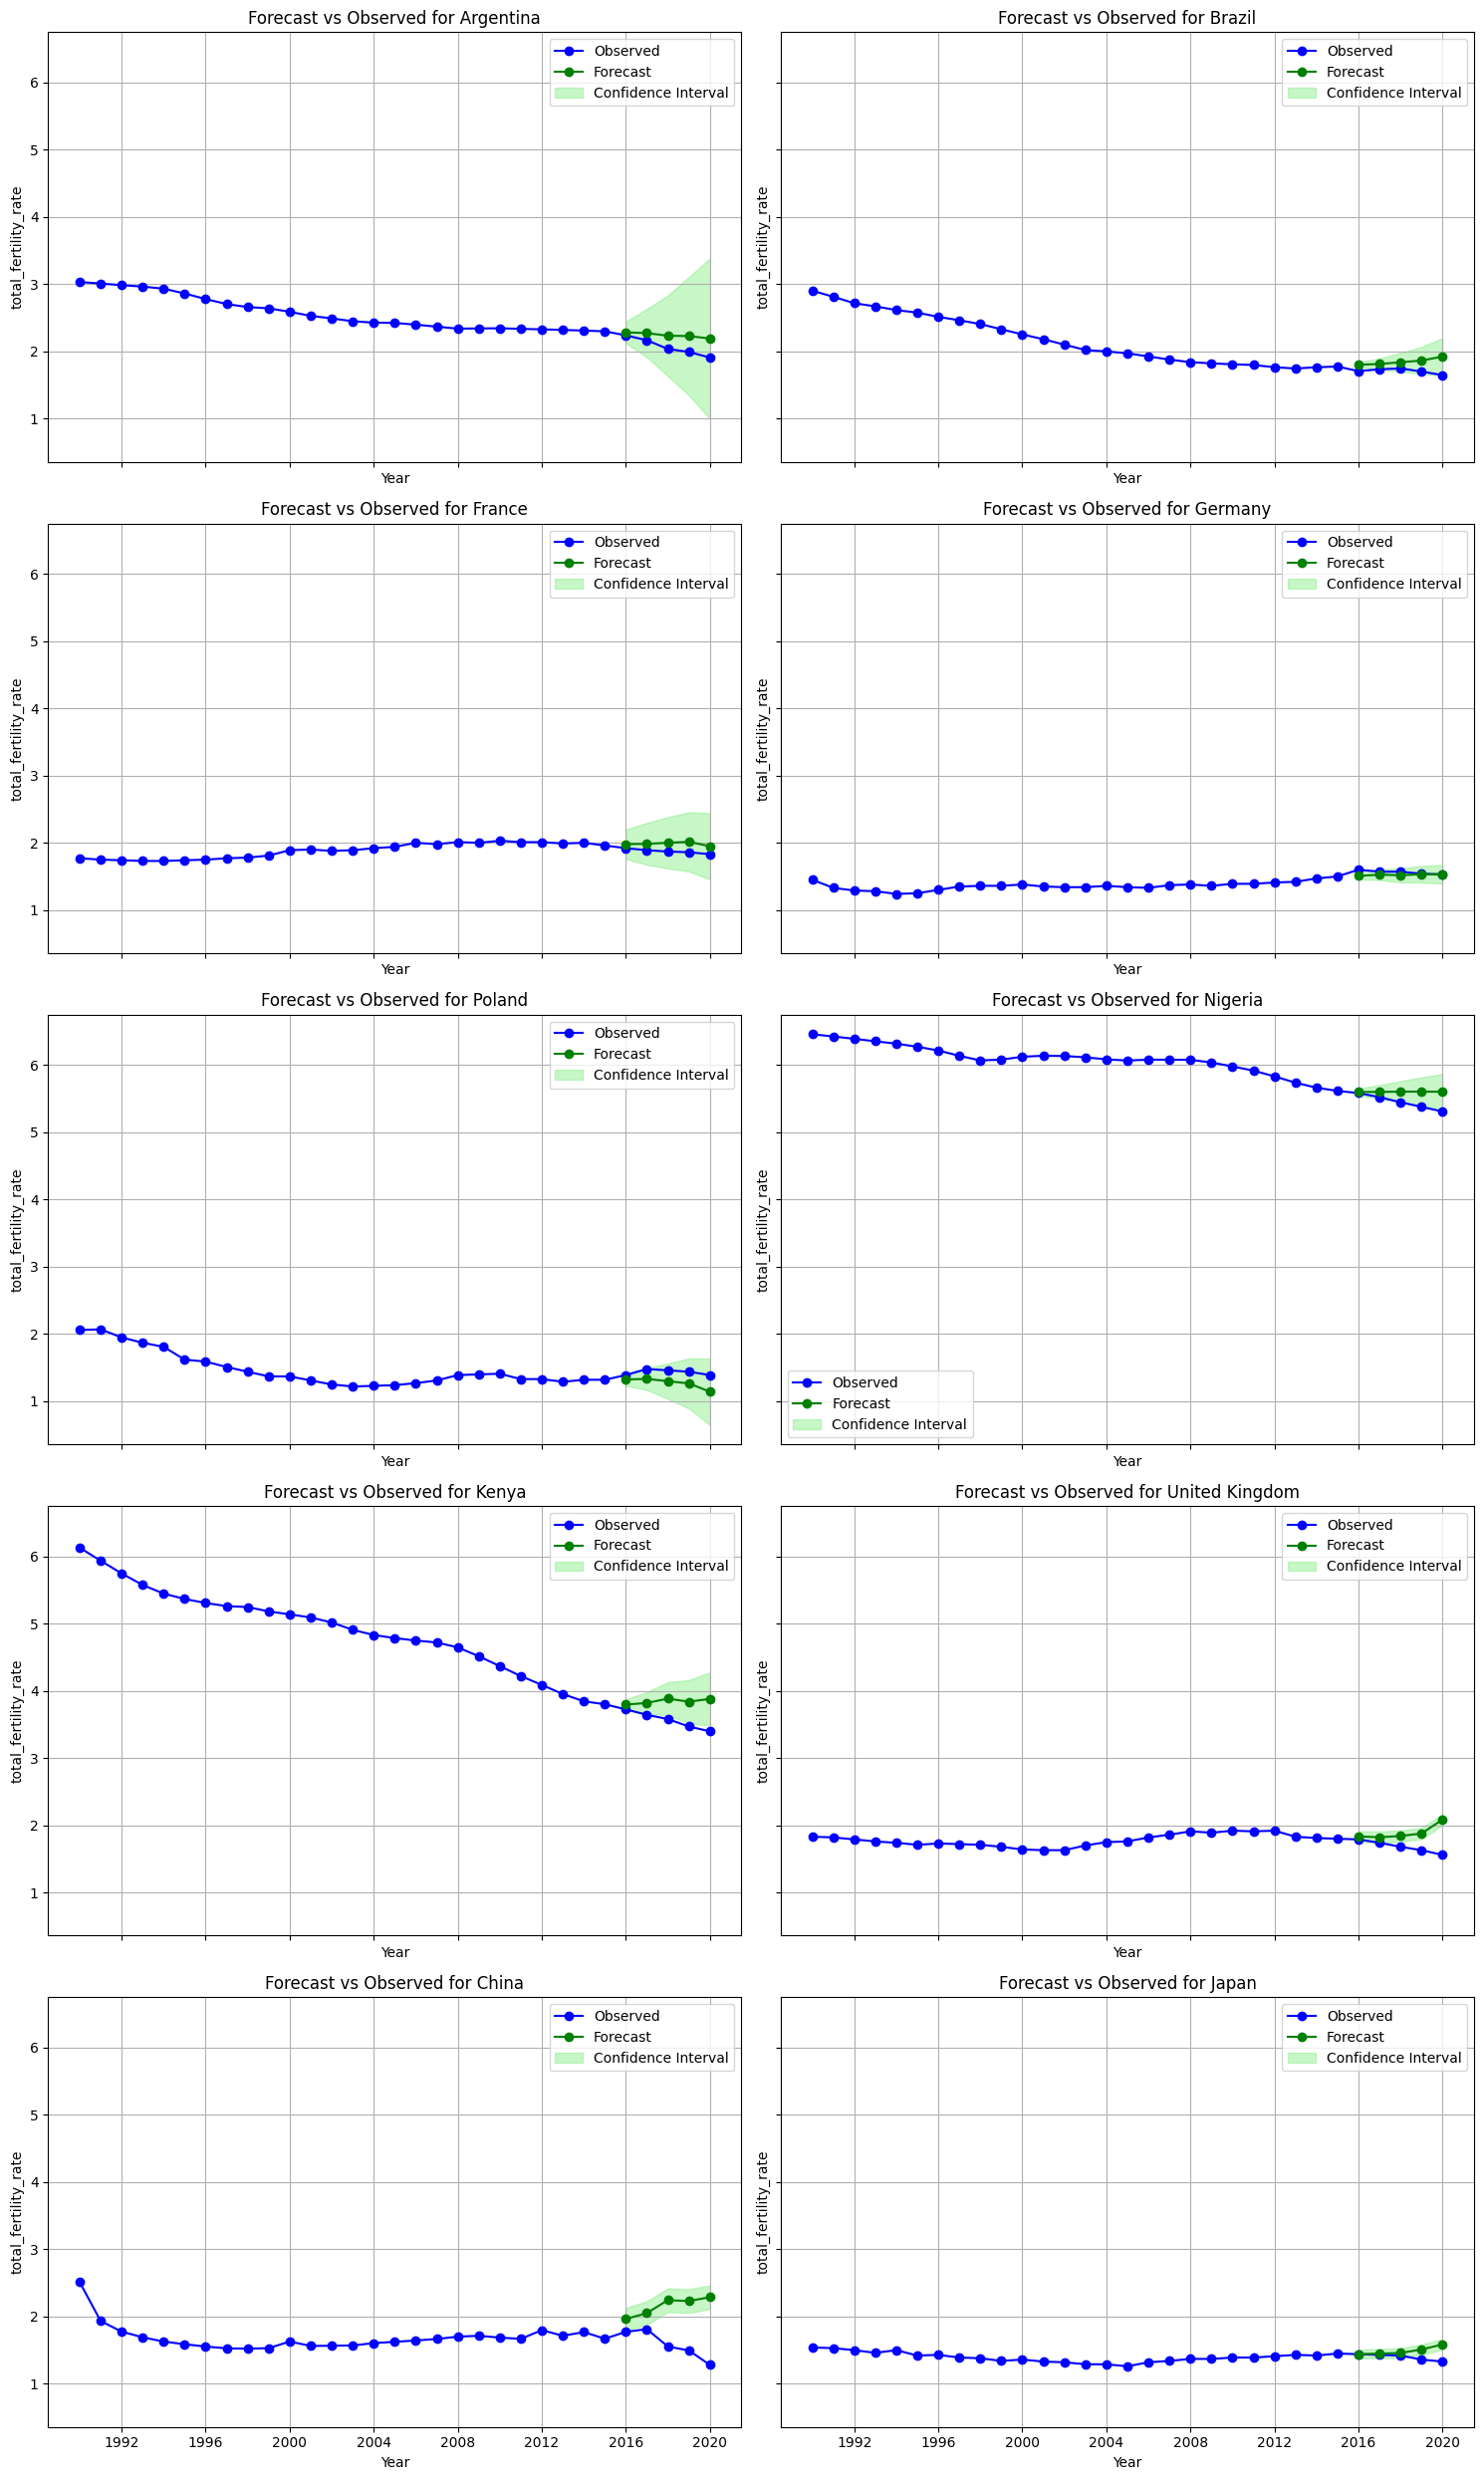

In [8]:
# Define the number of rows and columns for the plot grid
num_countries = len(df_test[COUNTRY_COL].unique())
num_cols = 2
num_rows = (num_countries + 1) // num_cols

fig, axes = plt.subplots(
    num_rows, num_cols, figsize=(15, num_rows * 5), sharex=True, sharey=True
)
axes = axes.flatten()

# Generate forecasts and plot for each country
for i, country in enumerate(df_test[COUNTRY_COL].unique()):
    country_df_train = df_train[df_train[COUNTRY_COL] == country]
    country_df_test = df_test[df_test[COUNTRY_COL] == country]
    country_df = df[df[COUNTRY_COL] == country]

    model_fit = sarmiax_models_per_country[country]

    forecast_steps = len(country_df_test)
    forecast = model_fit.get_forecast(
        steps=forecast_steps, exog=country_df_test[X_VARS]
    )
    forecast_mean = forecast.predicted_mean
    forecast_ci = forecast.conf_int()

    ax = axes[i]
    ax.plot(
        country_df.index.to_timestamp(),
        country_df[Y_COL],
        label="Observed",
        marker="o",
        color="blue",
    )
    ax.plot(
        forecast_mean.index.to_timestamp(),
        forecast_mean,
        label="Forecast",
        marker="o",
        color="green",
    )
    ax.fill_between(
        forecast_ci.index.to_timestamp(),
        forecast_ci.iloc[:, 0],
        forecast_ci.iloc[:, 1],
        color="lightgreen",
        alpha=0.5,
        label="Confidence Interval",
    )

    ax.set_title(f"Forecast vs Observed for {country}")
    ax.set_xlabel("Year")
    ax.set_ylabel(Y_COL)
    ax.legend()
    ax.grid()

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig("forecast_vs_observed.png")
plt.show()

In [9]:
def forecast_with_regressor_arima(sarimax_model, y_series, x_df, steps):
    """
    Forecast using a SARIMAX model with exogenous variables using ARIMA
    forecasted regressors.
    """

    # Forecast each regressor for the specified number of steps
    regressor_preds = []
    for col in x_df.columns:
        arima = auto_arima(
            x_df[col],
            seasonal=False,
            stepwise=True,
            suppress_warnings=True,
            error_action="ignore",
        )
        regressor_preds.append(arima.predict(n_periods=steps))

    regressor_preds = np.column_stack(regressor_preds)
    # Create a future index for exogenous forecasts
    future_index = pd.period_range(
        start=y_series.index[-1] + 1, periods=steps, freq=y_series.index.freq
    )
    predicted_exog = pd.DataFrame(
        regressor_preds, columns=x_df.columns, index=future_index
    )

    # Forecast using the SARIMAX model (already fitted)
    forecast_res = sarimax_model.get_forecast(steps=steps, exog=predicted_exog)
    return forecast_res.predicted_mean, forecast_res.conf_int(), predicted_exog

Refit SARIMAX models on full data

In [11]:
full_sarmiax_models_per_country = {}

for country in df[COUNTRY_COL].unique():
    # Gather the entire data for this country
    country_data = df[df[COUNTRY_COL] == country]
    y_series = country_data[Y_COL]
    x_exog = country_data[X_VARS]

    # Fit a new SARIMAX model using the full dataset
    model = SARIMAX(
        endog=y_series,
        exog=x_exog,
        order=orders_per_country[country],
        enforce_stationarity=False,
        enforce_invertibility=False,
    )

    model_fit = model.fit()

    full_sarmiax_models_per_country[country] = model_fit

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            6     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f= -1.25830D+00    |proj g|=  3.04933D+02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    6      1     21      1     0     0   3.049D+02  -1.258D+00
  F =  -1.2582994940033085     

ABNORMAL_TERMINATION_IN_LNSRCH                              
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            6     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f= -8.2

 This problem is unconstrained.
/Users/kacperkedzierski/Documents/Code/Repositories/fertility-prognosing/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "

 Line search cannot locate an adequate point after MAXLS
  function and gradient evaluations.
  Previous x, f and g restored.
 Possible causes: 1 error in function or gradient evaluation;
                  2 rounding error dominate computation.
 This problem is unconstrained.

 Bad direction in the line search;
   refresh the lbfgs memory and restart the iteration.

   evaluations in the last line search.  Termination
   may possibly be caused by a bad search direction.
 This problem is unconstrained.
/Users/kacperkedzierski/Documents/Code/Repositories/fertility-prognosing/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Lik

At iterate    5    f= -1.62028D+00    |proj g|=  7.43448D+00

At iterate   10    f= -1.72898D+00    |proj g|=  7.74965D+00

At iterate   15    f= -1.73886D+00    |proj g|=  6.44081D+00

At iterate   20    f= -1.82794D+00    |proj g|=  1.42358D+01

At iterate   25    f= -1.83906D+00    |proj g|=  6.40969D+01

At iterate   30    f= -2.10237D+00    |proj g|=  1.72222D+02

At iterate   35    f= -2.12793D+00    |proj g|=  2.88593D+00

At iterate   40    f= -2.12796D+00    |proj g|=  1.14557D+00

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    9     42     62      1     0     0   8.611D-01  -2.128D+00
  F =  -2.127972215475

 This problem is unconstrained.

 Bad direction in the line search;
   refresh the lbfgs memory and restart the iteration.
/Users/kacperkedzierski/Documents/Code/Repositories/fertility-prognosing/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "

 Line search cannot locate an adequate point after MAXLS
  function and gradient evaluations.
  Previous x, f and g restored.
 Possible causes: 1 error in function or gradient evaluation;
                  2 rounding error dominate computation.
 This problem is unconstrained.

 Bad direction in the line search;
   refresh the lbfgs memory and restart the iteration.
/Users/kacperkedzierski/Documents/Code/Repositories/fertility-prognosing/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check m

Forecast next 5 periods

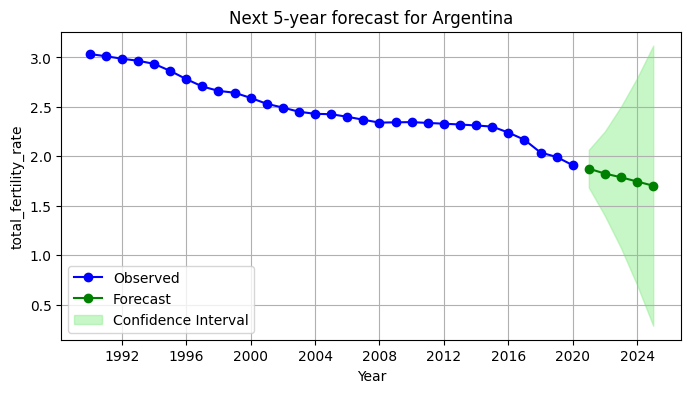

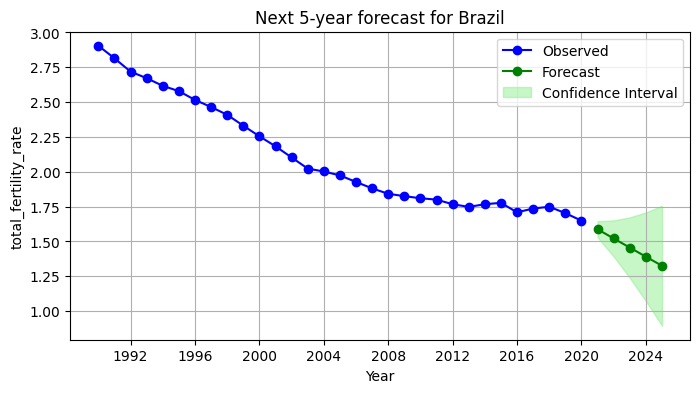

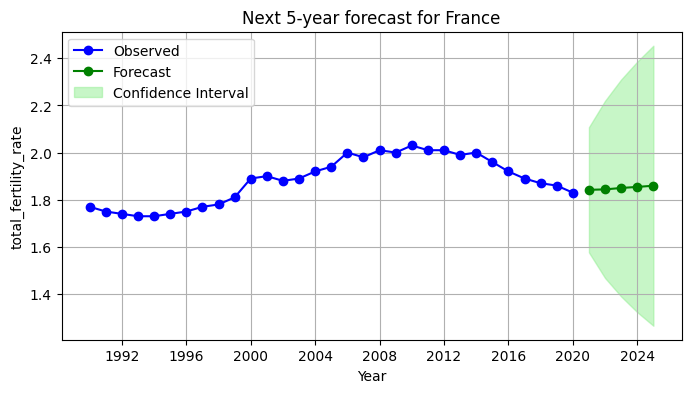

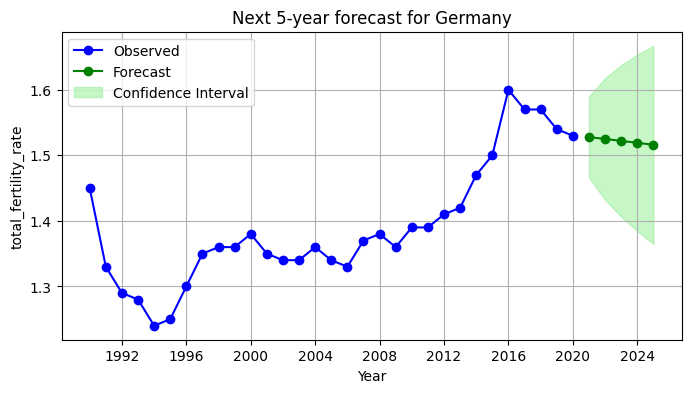

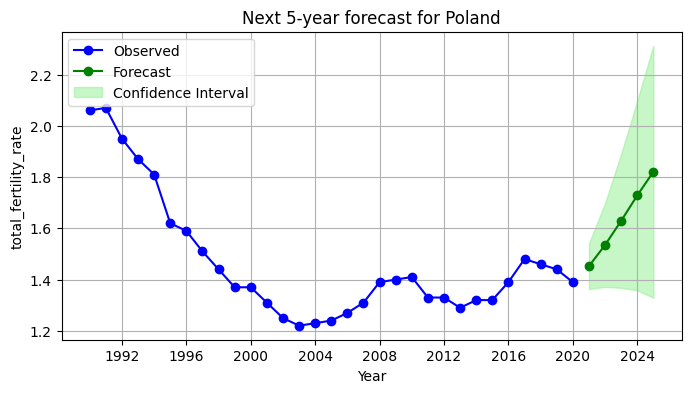

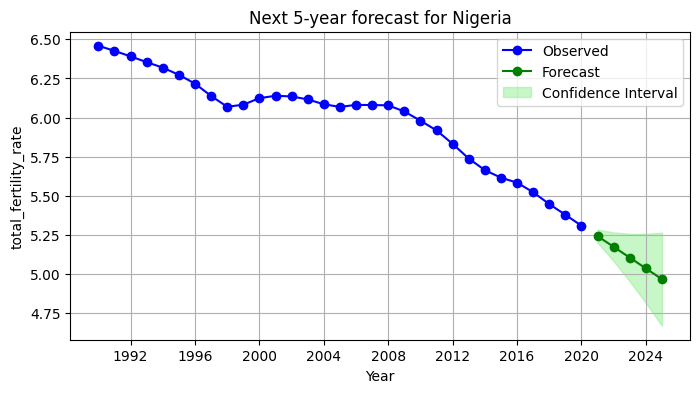

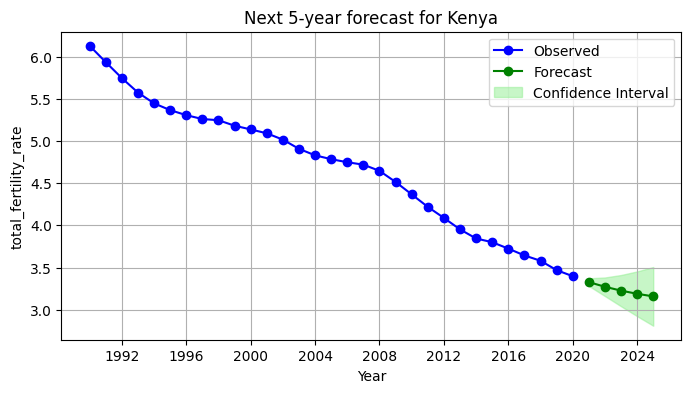

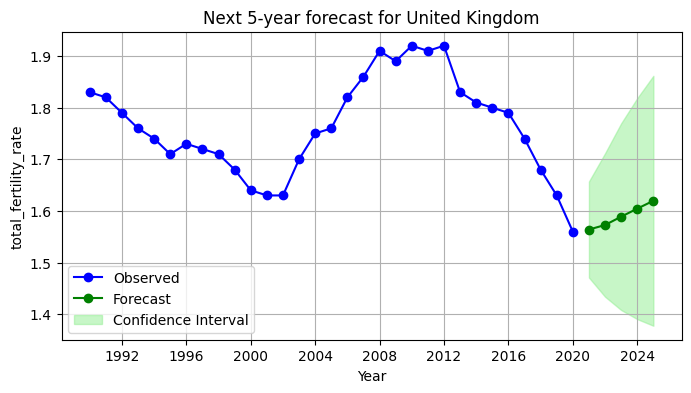

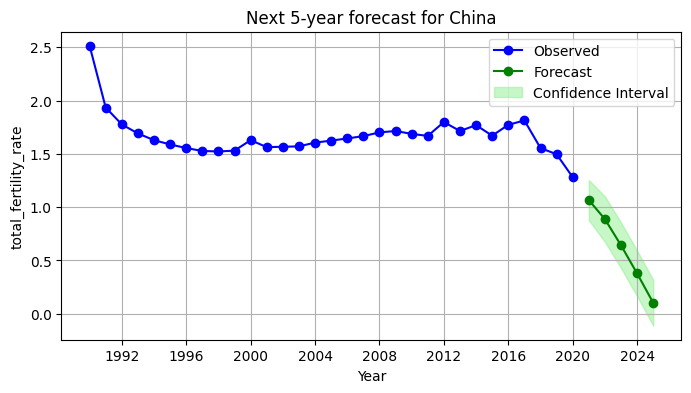

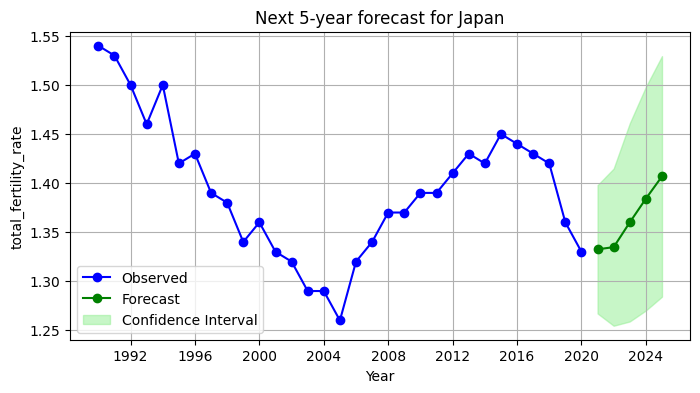

In [12]:
steps_to_forecast = 5

for country in df[COUNTRY_COL].unique():
    # Get the fitted SARIMAX model
    model_fit = full_sarmiax_models_per_country[country]

    # Split the dataframe for this country
    country_data = df[df[COUNTRY_COL] == country]
    y_series = country_data[Y_COL]
    x_exog = country_data[X_VARS]

    # Get forecasts
    forecast_mean, forecast_ci, predicted_exog = forecast_with_regressor_arima(
        model_fit, y_series, x_exog, steps_to_forecast
    )

    # Plot the results
    plt.figure(figsize=(8, 4))
    plt.plot(
        y_series.index.to_timestamp(),
        y_series,
        label="Observed",
        marker="o",
        color="blue",
    )
    plt.plot(
        forecast_mean.index.to_timestamp(),
        forecast_mean,
        label="Forecast",
        marker="o",
        color="green",
    )
    plt.fill_between(
        forecast_ci.index.to_timestamp(),
        forecast_ci.iloc[:, 0],
        forecast_ci.iloc[:, 1],
        color="lightgreen",
        alpha=0.5,
        label="Confidence Interval",
    )
    plt.title(f"Next 5-year forecast for {country}")
    plt.xlabel("Year")
    plt.ylabel(Y_COL)
    plt.legend()
    plt.grid()
    plt.show()

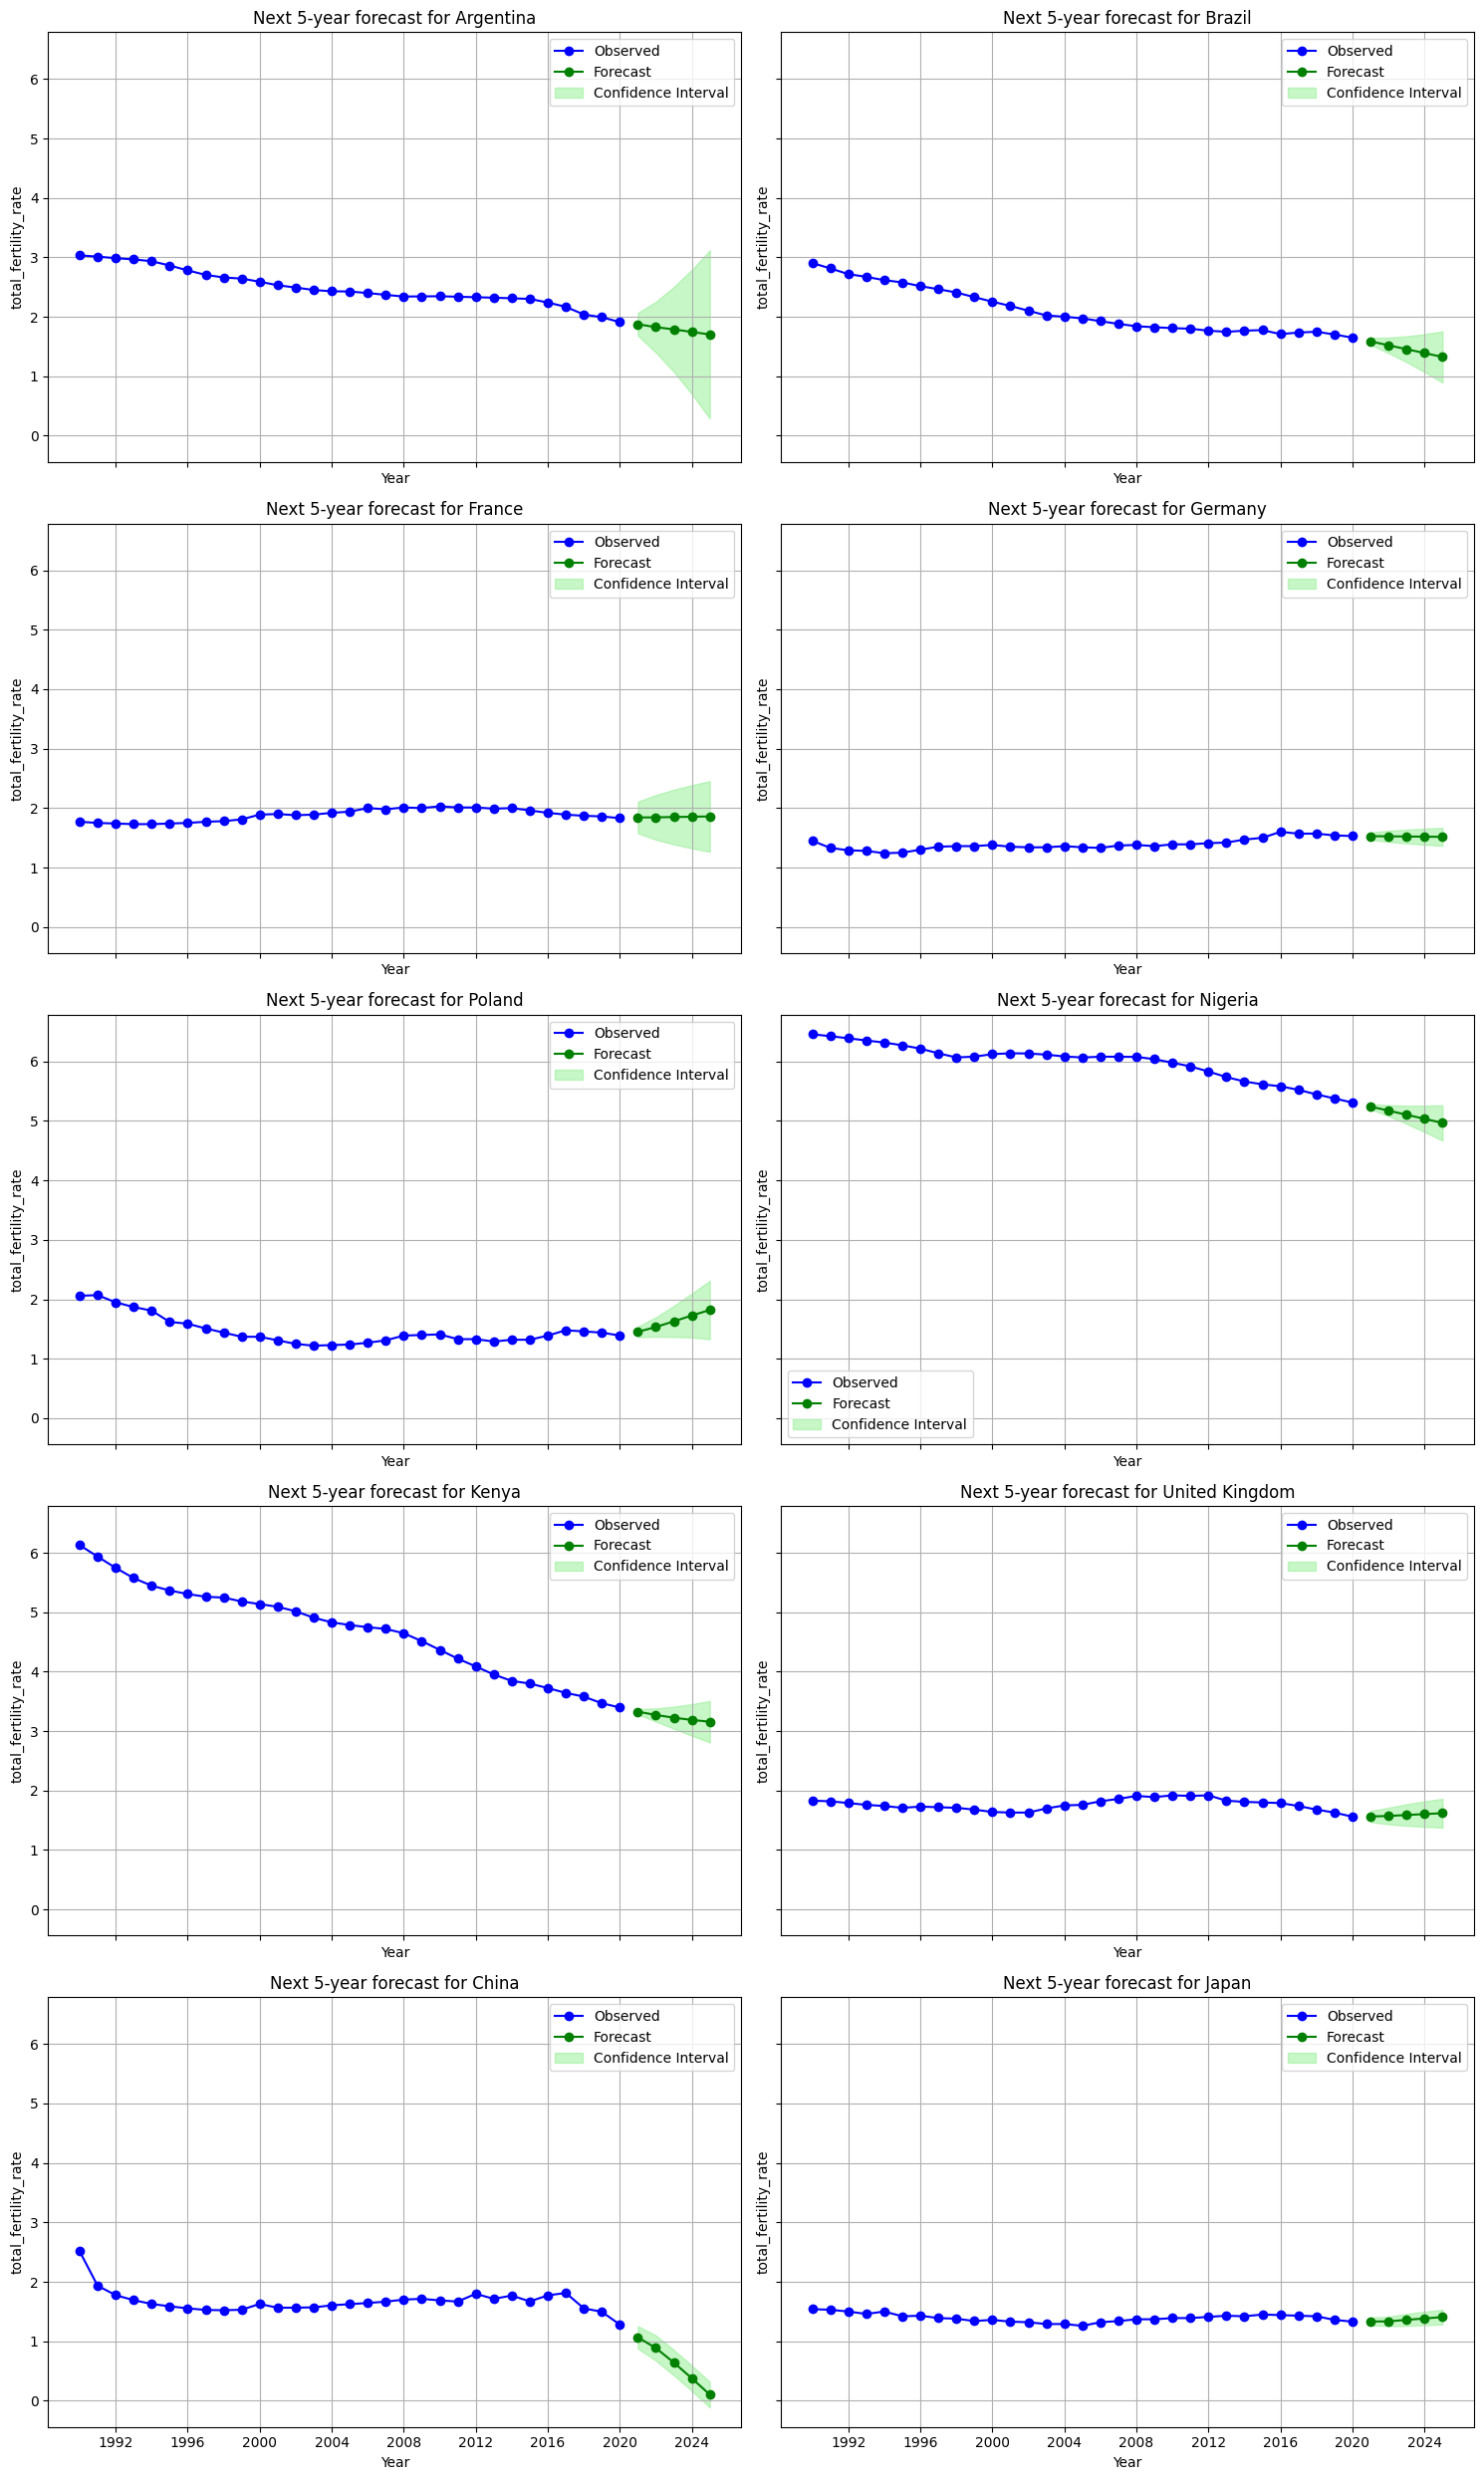

In [13]:
steps_to_forecast = 5

num_countries = len(df[COUNTRY_COL].unique())
num_cols = 2
num_rows = (num_countries + 1) // num_cols

fig, axes = plt.subplots(
    num_rows, num_cols, figsize=(15, num_rows * 5), sharex=True, sharey=True
)
axes = axes.flat

for i, country in enumerate(df[COUNTRY_COL].unique()):
    model_fit = full_sarmiax_models_per_country[country]
    country_data = df[df[COUNTRY_COL] == country]
    y_series = country_data[Y_COL]
    x_exog = country_data[X_VARS]

    forecast_mean, forecast_ci, predicted_exog = forecast_with_regressor_arima(
        model_fit, y_series, x_exog, steps_to_forecast
    )

    ax = axes[i]
    ax.plot(
        y_series.index.to_timestamp(),
        y_series,
        label="Observed",
        marker="o",
        color="blue",
    )
    ax.plot(
        forecast_mean.index.to_timestamp(),
        forecast_mean,
        label="Forecast",
        marker="o",
        color="green",
    )
    ax.fill_between(
        forecast_ci.index.to_timestamp(),
        forecast_ci.iloc[:, 0],
        forecast_ci.iloc[:, 1],
        color="lightgreen",
        alpha=0.5,
        label="Confidence Interval",
    )
    ax.set_title(f"Next 5-year forecast for {country}")
    ax.set_xlabel("Year")
    ax.set_ylabel(Y_COL)
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.savefig("next_5_years_forecast.png")
plt.show()